# 03 株式・暗号資産・マクロ・センチメント・需給データ収集

| 項目 | 内容 |
|------|------|
| 目的 | コア銘柄(yfinance)の株価に加え、FRED・alternative.me・JPX・J-Quants など取得済みAPIキーで利用可能な追加データソースを収集する |
| 出力 | `data/equity_jp_ohlcv.parquet`, `data/crypto_ohlcv.parquet`, `data/macro.parquet`, `data/fred_macro.parquet`, `data/sentiment.parquet`, `data/supply_demand.parquet`, `data/universe_instruments.parquet`, `data/universe_ohlcv_sample.parquet` |
| 注意 | raw data は読み取り専用。前処理済みデータは processed_data/ に保存。FRED/J-Quantsは `Analytics/.env` の `FRED_API_KEY` / `JQUANTS_API_KEY` が実キーの場合のみ動作し、未設定時は空データで安全にスキップされる |

### データソース一覧
| セクション | データ | 取得元 | 認証 |
|---|---|---|---|
| 2 | JP株式 OHLCV (コア銘柄) | yfinance | 不要 |
| 4 | 暗号資産 OHLCV | yfinance | 不要 |
| 5 | マクロ指標 (市場ベース: 日経・ドル指数・原油等) | yfinance | 不要 |
| 6 | マクロ指標 (公式統計: 金利・CPI・失業率) | FRED API | 要APIキー |
| 7 | センチメント (VIXスコア・暗号資産Fear&Greed) | yfinance VIX / alternative.me | 不要 |
| 8 | 需給指標 (投資部門別売買・信用残高・空売り比率) | JPX統計 | 不要(スクレイピング) |
| 9 | 広いユニバース (東証全上場銘柄マスタ+株価サンプル) | J-Quants API | 要APIキー |

---
## 0. 環境セットアップ

In [ ]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import yaml

try:
    import japanize_matplotlib
except ImportError:
    pass

sys.path.append(str(Path('../../').resolve()))
from funcs import macro_collector, sentiment_collector, supply_demand_collector, universe_collector

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

print('Setup OK')

---
## 1. 設定読み込み

In [3]:
CFG_PATH = Path('../../configs/stock_config.yaml')
with open(CFG_PATH, encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DATA_DIR      = Path(cfg['paths']['data'])
PROCESSED_DIR = Path(cfg['paths']['processed_data'])
FIGURES_DIR   = Path(cfg['paths']['figures'])
DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_START     = cfg['equity']['data_start']
EQUITY_SYMBOLS = cfg['equity']['symbols']
CRYPTO_SYMBOLS = cfg['crypto']['symbols']
RANDOM_SEED    = cfg.get('random_seed', 42)

print(f'Data start : {DATA_START}')
print(f'Equity     : {len(EQUITY_SYMBOLS)} 銘柄')
print(f'Crypto     : {len(CRYPTO_SYMBOLS)} シンボル')
print(f'Data dir   : {DATA_DIR.resolve()}')

Data start : 2020-01-01
Equity     : 25 銘柄
Crypto     : 5 シンボル
Data dir   : C:\Users\hngka\Project\DataScience\StockPrediction\Analytics\notebooks\data


---
## 2. 日本株 OHLCV 収集

In [5]:
from datetime import datetime

def download_ohlcv(symbols, start, end=None, asset_class='equity_jp'):
    if end is None:
        end = datetime.today().strftime('%Y-%m-%d')
    print(f'ダウンロード: {len(symbols)} 銘柄  {start} ~ {end}')
    raw = yf.download(symbols, start=start, end=end, auto_adjust=True, progress=True)
    records = []
    for sym in symbols:
        try:
            df_s = raw.xs(sym, level=1, axis=1).copy() if len(symbols) > 1 else raw.copy()
            df_s = df_s.dropna(subset=['Close'])
            if df_s.empty:
                continue
            df_s['symbol'] = sym
            df_s.index.name = 'date'
            df_s = df_s.reset_index()
            df_s.columns = [c.lower() if c != 'date' else c for c in df_s.columns]
            records.append(df_s)
        except Exception as e:
            print(f'  WARN [{sym}]: {e}')
    if not records:
        return pd.DataFrame()
    df = pd.concat(records, ignore_index=True)
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None)
    df['asset_class'] = asset_class
    cols = ['symbol', 'asset_class', 'date', 'open', 'high', 'low', 'close', 'volume']
    return df[cols].sort_values(['symbol', 'date']).reset_index(drop=True)


df_equity = download_ohlcv(EQUITY_SYMBOLS, start=DATA_START)
print(f'\n行数   : {len(df_equity):,}')
print(f'銘柄数 : {df_equity["symbol"].nunique()}')
print(f'期間   : {df_equity["date"].min().date()} ~ {df_equity["date"].max().date()}')
df_equity.head()

ダウンロード: 25 銘柄  2020-01-01 ~ 2026-07-19


[*********************100%***********************]  25 of 25 completed



行数   : 39,925
銘柄数 : 25
期間   : 2020-01-06 ~ 2026-07-17


,symbol,asset_class,date,open,high,low,close,volume
0,3382.T,equity_jp,2020-01-06,1146.6422,1146.6422,1123.7094,1126.3220,7056000
1,3382.T,equity_jp,2020-01-07,1132.1275,1155.3506,1129.8052,1152.1575,6325800
2,3382.T,equity_jp,2020-01-08,1150.4159,1159.9954,1132.9985,1144.3198,6858900
3,3382.T,equity_jp,2020-01-09,1152.4480,1171.0264,1149.8354,1167.5430,5787600
4,3382.T,equity_jp,2020-01-10,1206.1512,1222.1172,1194.5396,1210.7959,11772300


---
## 3. データ品質チェック

In [6]:
print('=== 基本情報 ===')
print(df_equity.dtypes)

print('\n=== 欠損値 ===')
missing = df_equity[['open','high','low','close','volume']].isnull().sum()
print(missing[missing > 0] if (missing > 0).any() else '  欠損なし')

print('\n=== 銘柄別日数 (下位 5 件) ===')
by_sym = df_equity.groupby('symbol').size().rename('days').reset_index()
print(by_sym.sort_values('days').head())

print('\n=== 統計量 (close) ===')
print(df_equity.groupby('symbol')['close'].describe().T)

=== 基本情報 ===
symbol                 object
asset_class            object
date           datetime64[ns]
open                  float64
high                  float64
low                   float64
close                 float64
volume                  int64
dtype: object

=== 欠損値 ===
  欠損なし

=== 銘柄別日数 (下位 5 件) ===
    symbol  days
0   3382.T  1597
22  9432.T  1597
21  8766.T  1597
20  8316.T  1597
19  8306.T  1597

=== 統計量 (close) ===
symbol    3382.T    4063.T    4502.T     4519.T    4568.T    5108.T  \
count  1597.0000 1597.0000 1597.0000  1597.0000 1597.0000 1597.0000   
mean   1726.8697 4108.5163 3632.5879  4946.2143 3467.9366 2398.7418   
std     380.1101 1336.0624  728.1142  1703.3162  882.4974  627.5807   
min     897.6652 1567.1057 2164.3323  2937.9031 1701.7825 1191.1622   
25%    1497.2008 3182.9165 3010.9329  3551.5212 2741.6931 2018.2008   
50%    1809.1423 3787.3867 3694.7485  4252.7568 3366.0415 2366.7720   
75%    1971.4893 4981.5908 3996.4062  6416.8950 4087.1113 2861.1680  

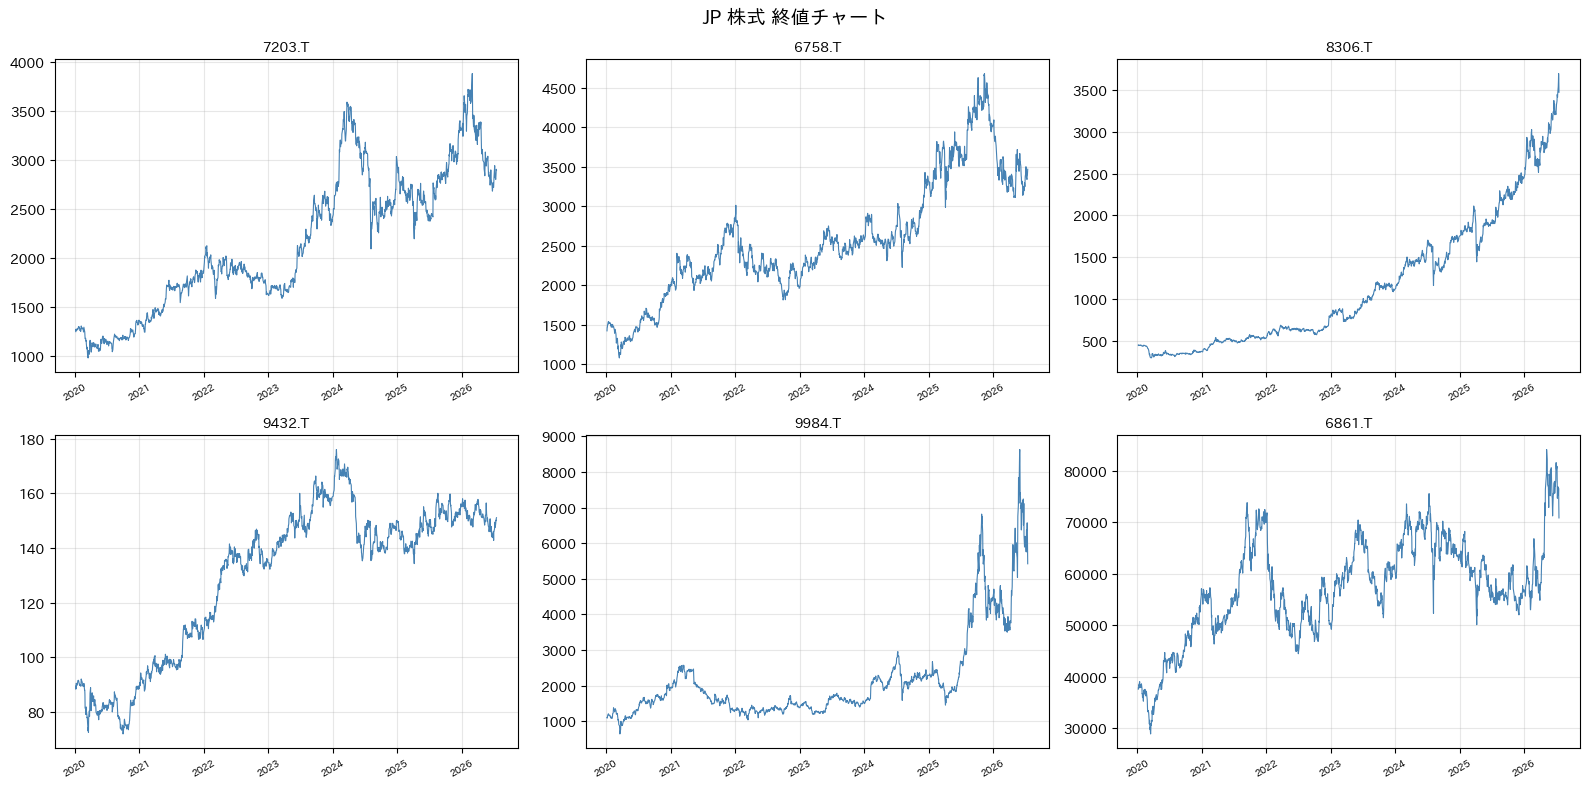

保存: ..\results\figures\03_equity_price_chart.png


In [7]:
# 代表 6 銘柄のチャート
sample = EQUITY_SYMBOLS[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, sym in zip(axes.flatten(), sample):
    df_s = df_equity[df_equity['symbol'] == sym]
    ax.plot(df_s['date'], df_s['close'], linewidth=0.8, color='steelblue')
    ax.set_title(sym, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(alpha=0.3)
plt.suptitle('JP 株式 終値チャート', fontsize=14)
plt.tight_layout()
path = FIGURES_DIR / '03_equity_price_chart.png'
plt.savefig(path, dpi=120, bbox_inches='tight')
plt.show()
print(f'保存: {path}')

---
## 4. 暗号資産 OHLCV 収集

In [8]:
df_crypto = download_ohlcv(CRYPTO_SYMBOLS, start=DATA_START, asset_class='crypto')
print(f'行数   : {len(df_crypto):,}')
print(f'期間   : {df_crypto["date"].min().date()} ~ {df_crypto["date"].max().date()}')
df_crypto.head()

ダウンロード: 5 銘柄  2020-01-01 ~ 2026-07-19


[*********************100%***********************]  5 of 5 completed

行数   : 11,855
期間   : 2020-01-01 ~ 2026-07-18


,symbol,asset_class,date,open,high,low,close,volume
0,BNB-USD,crypto,2020-01-01,13.7310,13.8739,13.6549,13.6891,172980718.0000
1,BNB-USD,crypto,2020-01-02,13.6981,13.7155,12.9900,13.0270,156376427.0000
2,BNB-USD,crypto,2020-01-03,13.0353,13.7637,13.0126,13.6605,173683857.0000
3,BNB-USD,crypto,2020-01-04,13.6674,13.9219,13.5600,13.8915,182230374.0000
4,BNB-USD,crypto,2020-01-05,13.8883,14.4108,13.8865,14.1110,202552703.0000


---
## 5. マクロ指標収集

In [ ]:
MACRO_TICKERS = cfg.get('macro_tickers', {
    '^N225':    'nikkei225',
    'DX-Y.NYB': 'usd_index',
    'USDJPY=X': 'usdjpy',
    '^TNX':     'us10y_yield',
    'CL=F':     'crude_oil',
    'GC=F':     'gold',
    '^VIX':     'vix',
})

series_list = []
for ticker, name in MACRO_TICKERS.items():
    try:
        s = yf.download(ticker, start=DATA_START, auto_adjust=True, progress=False)['Close']
        # 新しいyfinanceでは単一銘柄でも DataFrame (1列) が返ることがあり、
        # その場合 s.name = name は列名に反映されない (実行結果が ^N225 等の生ティッカーになる不具合)。
        # Series化してから明示的に rename することで確実に友好的な名前を付与する。
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        s = s.rename(name)
        series_list.append(s)
        print(f'  OK: {ticker:15s} -> {name}')
    except Exception as e:
        print(f'  WARN: {ticker}: {e}')

df_macro = pd.concat(series_list, axis=1).reset_index()
df_macro = df_macro.rename(columns={df_macro.columns[0]: 'Date'})
df_macro['Date'] = pd.to_datetime(df_macro['Date']).dt.tz_localize(None)
df_macro = df_macro.sort_values('Date').set_index('Date').ffill().reset_index()
print(f'\nマクロ: {len(df_macro):,} 行 x {df_macro.shape[1]-1} 指標')
df_macro.tail()

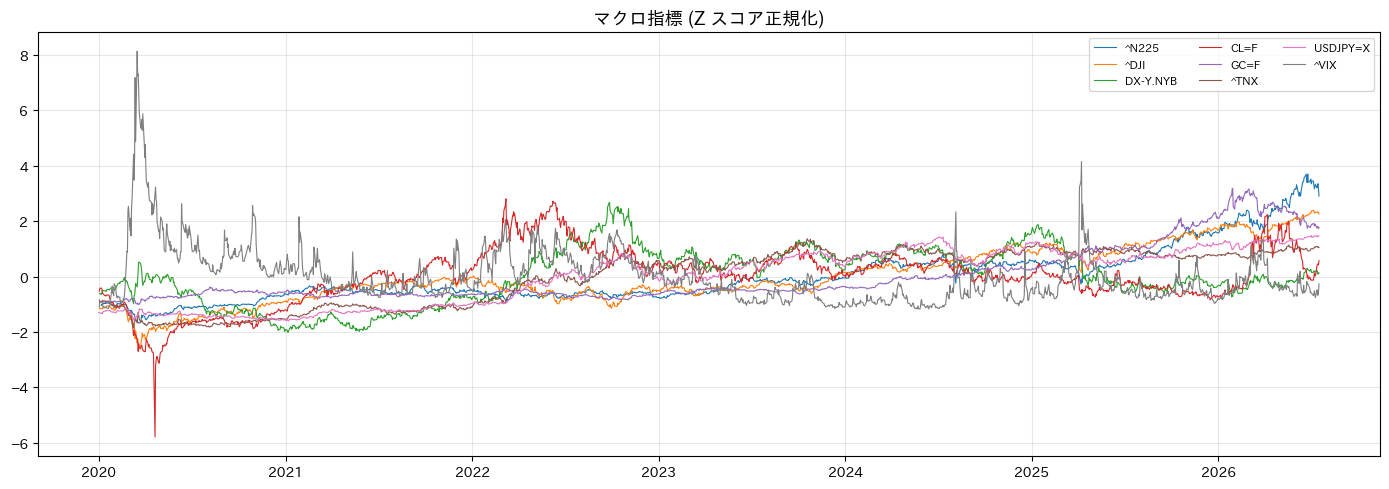

In [13]:
# マクロ指標の正規化プロット
macro_cols = [c for c in df_macro.columns if c != 'Date']
fig, ax = plt.subplots(figsize=(14, 5))
for col in macro_cols:
    s = df_macro[col].dropna()
    s_norm = (s - s.mean()) / s.std()
    ax.plot(df_macro.loc[s.index, 'Date'], s_norm, label=col, linewidth=0.8)
ax.set_title('マクロ指標 (Z スコア正規化)', fontsize=13)
ax.legend(ncol=3, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. マクロ指標収集 (FRED, 公式統計)

yfinanceのマクロ指標は市場価格ベース(日経平均・ドル指数等)だが、政策金利・CPI・失業率などの
公式統計はFREDが一次情報源として適切 (`docs/api_setup_guide.md` 6章参照)。
`FRED_API_KEY` が未設定/ダミーの場合は空データを返し、後続処理は安全にスキップされる。

In [ ]:
df_fred = macro_collector.download_macro_fred(start=DATA_START)

if not df_fred.empty:
    print(f'FRED マクロ: {len(df_fred):,} 行 x {df_fred.shape[1]-1} 系列')
    display(df_fred.tail())
else:
    print('FRED_API_KEY が未設定/ダミーのため空データです。')
    print('取得するには Analytics/.env の FRED_API_KEY を実キーに差し替えてください')
    print('(docs/api_setup_guide.md 6章、https://fredaccount.stlouisfed.org/apikeys で無料発行)')

---
## 7. センチメント指標収集

株式向け: yfinance取得済みのVIX系列からレベル・変化率・トレーリングz-scoreを算出。
暗号資産向け: alternative.me Fear & Greed Index (認証不要)。

In [ ]:
# df_macro の列名は yaml の macro_tickers 値 (^VIX -> 'vix') を使用
df_macro_for_vix = df_macro.rename(columns={'Date': 'date'})
df_vix_sentiment = sentiment_collector.compute_vix_sentiment(df_macro_for_vix)

df_feargreed = sentiment_collector.fetch_fear_greed_index(limit=0)

print(f'VIXセンチメント: {len(df_vix_sentiment):,} 行')
if not df_vix_sentiment.empty:
    display(df_vix_sentiment.tail())

print(f'\nFear & Greed Index (暗号資産): {len(df_feargreed):,} 行')
if not df_feargreed.empty:
    display(df_feargreed.tail())

---
## 8. 需給指標収集 (JPX統計)

投資部門別売買状況(外国人売買動向)・信用取引残高・空売り比率。認証不要だがJPXページの
構成変化でライブ取得が失敗することがあり、その場合は `Analytics/data/jpx_manual/` に手動配置した
ファイルへ自動フォールバックする (詳細: 同ディレクトリの README.md)。

In [ ]:
df_flows = supply_demand_collector.fetch_jpx_investor_flows()
df_margin = supply_demand_collector.fetch_jpx_margin_balance()
df_short = supply_demand_collector.fetch_jpx_short_selling_ratio()

df_supply_demand = pd.concat([df_flows, df_margin, df_short], ignore_index=True)
print(f'需給指標: {len(df_supply_demand):,} 行')
if not df_supply_demand.empty:
    print(df_supply_demand['metric_name'].value_counts())
    display(df_supply_demand.tail())
else:
    print('取得できませんでした。JPXページの構成が変わっている可能性があります。')
    print('手動DLしたファイルを Analytics/data/jpx_manual/ に配置すると自動的に読み込まれます。')

---
## 9. 広いユニバース (東証全上場銘柄, J-Quants)

コア銘柄(上記25銘柄)は手動選定のため大型株に偏る。急騰候補の検知など広い網が必要な分析では、
J-Quants `/equities/master` で東証全上場株式(約3,700〜3,900銘柄、時価総額でなく流動性で
足切りする設計。詳細は `Application/backend/lib/screening.py` 参照)を動的取得する。

株価の一括取得はJ-Quants無料プランのレート制限(約5req/分)により1営業日=1コールかかるため、
ここでは直近 `SAMPLE_DAYS` 日分のみをサンプル取得する。より長期間が必要な場合は
`Application/backend` の管理パネルから「広域株価取得」を実行するほうが実用的
(バックグラウンドでの長時間実行に対応済み)。

In [ ]:
df_universe = universe_collector.fetch_listed_instruments()

print(f'東証上場銘柄マスタ: {len(df_universe):,} 銘柄')
if not df_universe.empty:
    print(df_universe['market_segment'].value_counts())
    display(df_universe.head())
else:
    print('JQUANTS_API_KEY が未設定/ダミーのため空データです。')
    print('取得するには Analytics/.env の JQUANTS_API_KEY を実キーに差し替えてください')
    print('(docs/api_setup_guide.md 1章、https://jpx-jquants.com/ で無料登録)')

In [ ]:
# サンプル期間 (レート制限を考慮し既定は短め。必要に応じて調整)
SAMPLE_DAYS = 10
sample_end = pd.Timestamp.today()
sample_start = sample_end - pd.Timedelta(days=int(SAMPLE_DAYS * 1.5))  # 土日を考慮して少し広めに取る

if not df_universe.empty:
    df_universe_ohlcv = universe_collector.fetch_daily_quotes_range(
        start=sample_start.strftime('%Y-%m-%d'), end=sample_end.strftime('%Y-%m-%d')
    )
    print(f'\n広いユニバース株価サンプル: {len(df_universe_ohlcv):,} 行')
    if not df_universe_ohlcv.empty:
        print(f'銘柄数: {df_universe_ohlcv["symbol"].nunique():,} / 期間: '
              f'{df_universe_ohlcv["date"].min().date()} ~ {df_universe_ohlcv["date"].max().date()}')
        display(df_universe_ohlcv.head())
else:
    df_universe_ohlcv = pd.DataFrame()
    print('銘柄マスタが空のため株価サンプル取得をスキップします')

---
## 10. データ保存

In [ ]:
df_equity.to_parquet(DATA_DIR / 'equity_jp_ohlcv.parquet', index=False)
df_crypto.to_parquet(DATA_DIR / 'crypto_ohlcv.parquet', index=False)
df_macro.to_parquet(DATA_DIR / 'macro.parquet', index=False)

print('保存完了 (コア):')
print(f'  equity_jp_ohlcv.parquet  {len(df_equity):>8,} 行')
print(f'  crypto_ohlcv.parquet     {len(df_crypto):>8,} 行')
print(f'  macro.parquet            {len(df_macro):>8,} 行')

# ---- 追加データソース (空データの場合は保存をスキップし、次回APIキー設定後の再実行に委ねる) ----
optional_outputs = [
    ('fred_macro.parquet',           df_fred),
    ('sentiment_vix.parquet',        df_vix_sentiment),
    ('sentiment_feargreed.parquet',  df_feargreed),
    ('supply_demand.parquet',        df_supply_demand),
    ('universe_instruments.parquet', df_universe),
    ('universe_ohlcv_sample.parquet', df_universe_ohlcv),
]

print('\n保存完了 (追加データソース):')
for filename, df in optional_outputs:
    if df is not None and not df.empty:
        df.to_parquet(DATA_DIR / filename, index=False)
        print(f'  {filename:<32s} {len(df):>8,} 行')
    else:
        print(f'  {filename:<32s} {"(スキップ: 空データ)":>12s}')

print('\n次のステップ: 42_equity_lgbm_walkforward.ipynb でモデル構築')
print('             04_earnings_collection.ipynb で決算イベント(PEAD)データを収集')